In [1]:
import os
import re

import numpy as np
import torch
import pandas as pd
import matplotlib
import seaborn as sns
import pickle
from tqdm.notebook import tqdm
from scipy.interpolate import interp1d
from functionsgpu_old import *
from plotting_betas import *
from video_saving import *
from ci import *

import warnings
warnings.filterwarnings("ignore")

device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
tslen = 200

functionsgpu_old.py device: cuda:1


## Loading Data

In [2]:
def loading():
    with open('kendall_no_rot_align.pkl','rb') as f:
        betas = pickle.load(f)
    with open('kendall_euclidean_mean.pkl','rb') as f:
        mu = pickle.load(f)
    return betas, mu

betas_org, mu_all_t = loading()
# Standardize betas with sklearn StandardScaler (155 subjects, 32 landmarks, 3 x/y/z, 200 timepoints)
betas = betas_org.transpose(1, 2, 3, 0)
print(betas.shape)

(32, 3, 200, 155)


## Functional PCA and Skeleton Video

In [3]:
%matplotlib qt5
K = 32
M = 3
T = tslen
R = 38
nsamples = 155

betas_flat = betas.reshape((K*M*T, nsamples))
U, sigma, V_t = np.linalg.svd(betas_flat, full_matrices=False)
vec_reconstructed = U[:,0:R].reshape((K, M, T, R))

# P = U[:,0:R].T@tangent_flat
# Sigma = (P@P.T) / (P.shape[1]-1)
# print(Sigma)
# print(sigma[0:R]**2/(P.shape[1]-1))

lambdas = (sigma**2)/(nsamples-1)

betas_hat_t = []
scales = [-2, 0, 2]

for r in range(1):
    for s_id, scale in enumerate(scales):

      sigma_scaled = float(scale * np.sqrt(lambdas[r]))
      v_r  = sigma_scaled * vec_reconstructed[:, :, :, r]
      beta_t_hat = mu_all_t + v_r
      betas_hat_t.append(beta_t_hat)
    
    p_all = plotting_betas_landmark([betas_hat_t[-3], betas_hat_t[-2], betas_hat_t[-1]], 
                                    colors=[(1, 0, 0), (0, 0, 0), (0, 0.5, 1)], zoom = 3)
    # video_saving(p_all, 'FPCA{}'.format(r+1))

libGL error: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)
libGL error: failed to load driver: swrast



Cumulative variance explained:
First 1 components: 0.8385 (83.85%)
First 2 components: 0.9833 (98.33%)
First 3 components: 0.9873 (98.73%)
First 4 components: 0.9884 (98.84%)
First 5 components: 0.9893 (98.93%)
First 6 components: 0.9901 (99.01%)
First 7 components: 0.9907 (99.07%)
First 8 components: 0.9913 (99.13%)
First 9 components: 0.9918 (99.18%)
First 10 components: 0.9923 (99.23%)
First 11 components: 0.9928 (99.28%)
First 12 components: 0.9933 (99.33%)
First 13 components: 0.9937 (99.37%)
First 14 components: 0.9940 (99.40%)
First 15 components: 0.9943 (99.43%)
First 16 components: 0.9946 (99.46%)
First 17 components: 0.9949 (99.49%)
First 18 components: 0.9951 (99.51%)
First 19 components: 0.9953 (99.53%)
First 20 components: 0.9955 (99.55%)
First 21 components: 0.9957 (99.57%)
First 22 components: 0.9958 (99.58%)
First 23 components: 0.9960 (99.60%)
First 24 components: 0.9962 (99.62%)
First 25 components: 0.9963 (99.63%)
First 26 components: 0.9964 (99.64%)
First 27 compon

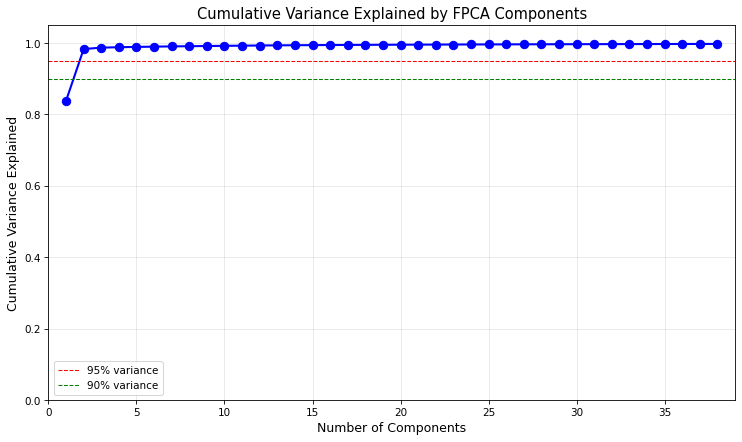


Number of components needed:
  For 90% variance: 2
  For 95% variance: 2


In [4]:
# Calculate cumulative variance explained
%matplotlib inline

# Variance explained by each component
variance_explained = lambdas / lambdas.sum()

# Cumulative variance explained
cumulative_variance = np.cumsum(variance_explained)

# Print results
# print("Variance explained by each component:")
# for i in range(min(20, len(variance_explained))):
#     print(f"Component {i+1}: {variance_explained[i]:.4f} ({variance_explained[i]*100:.2f}%)")

print("\nCumulative variance explained:")
for i in range(min(38, len(cumulative_variance))):
    print(f"First {i+1} components: {cumulative_variance[i]:.4f} ({cumulative_variance[i]*100:.2f}%)")

# Plot cumulative variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, min(39, len(cumulative_variance)+1)), cumulative_variance[:38], 'bo-', linewidth=2, markersize=8)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.axhline(y=0.90, color='g', linestyle='--', label='90% variance')
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Variance Explained', fontsize=12)
plt.title('Cumulative Variance Explained by FPCA Components', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(0, min(39, len(cumulative_variance)+1))
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

# Find number of components needed for 95% and 99% variance
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"\nNumber of components needed:")
print(f"  For 90% variance: {n_components_90}")
print(f"  For 95% variance: {n_components_95}")

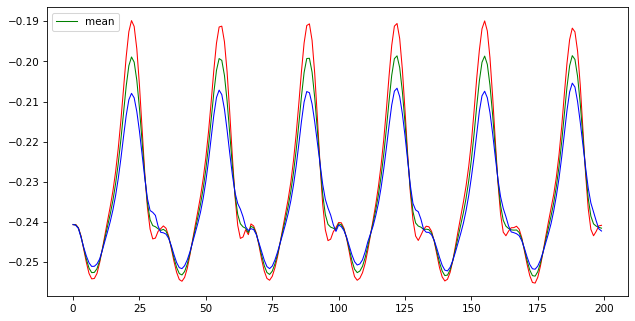

In [20]:
%matplotlib inline
plt.figure()
plt.plot(betas_hat_t[-3][30,2,:])
plt.plot(betas_hat_t[-2][30,2,:], label='mean')
plt.plot(betas_hat_t[-1][30,2,:])
plt.legend()

In [ ]:
# %matplotlib inline
# print(tangent_vec_all.shape)
# plt.plot(tangent_vec_all[30,2,:,10])
# plt.figure()
# plt.plot(betas_aligned_all[10][30,2,:])

In [4]:
R = 38
pc_cords = np.diag(sigma[0:R])@V_t[0:R,:]
X = pc_cords.T

folder_path = "/mnt/sdb/arafat/stroke_riemann/csv_r"
files = [file for file in os.listdir(folder_path)]
files = sorted(files, key=lambda x: int(x.split('_')[0][2:]))
scores = [file.split('_')[1] for file in files]
scores = [file.split('.')[0] for file in scores]

y = np.array(scores).astype(int)

# Same participant ID order as tcn_tangents.ipynb (from tangent_vecs, sorted by int ID)
def filter_valid_files(file_list):
    return [f for f in file_list if re.match(r'^ID\d+_\d+\.csv$', f.strip())]

csv_dir_tcn = "/mnt/sdb/arafat/stroke_riemann/tangent_vecs"
all_files_tcn = filter_valid_files(os.listdir(csv_dir_tcn))
all_participants = sorted({re.search(r'ID(\d+)_', f).group(1) for f in all_files_tcn}, key=lambda x: int(x))
# Participant ID for each row of X (same order as files from csv_r)
participant_ids = [re.search(r'ID(\d+)_', f).group(1) for f in files]
step = 10  # same as tcn_tangents: leave-10-participants-out per fold

print(X.shape, y.shape)
print("all_participants (first 15):", all_participants[:15])

(155, 38) (155,)
all_participants (first 15): ['1', '2', '3', '4', '5', '6', '7', '8', '10', '11', '13', '14', '15', '17', '18']


## Regression

In [5]:
def fpca_project(tangent_flat_train, tangent_flat_test, R=3):
    """Project train and test onto first R left singular vectors of train."""
    U, sigma, Vt = np.linalg.svd(tangent_flat_train, full_matrices=False)
    # Train: coordinates (n_train, R)
    X_train = (Vt[:R].T * sigma[:R])
    # Test: project onto U[:, :R]
    X_test = tangent_flat_test.T @ U[:, :R]
    return X_train, X_test

In [6]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from scipy import stats
import xgboost as xgb
from tqdm.notebook import tqdm

# Same CV: 5 validation + 5 test (disjoint) per fold, two rounds so every subject is validated and tested once.
n = len(y)
step_val = 5
step_test = 5
block_size = step_val + step_test
n_blocks = len(all_participants) // block_size
n_folds = 2 * n_blocks

models = {
    'KNN': KNeighborsRegressor(),
    'SVM': SVR(kernel='rbf'),
    'RF': RandomForestRegressor(random_state=42),
    'XGBoost': xgb.XGBRegressor(random_state=42),
    'MLP': MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42),
}

all_results_validation = {name: {'targets': [], 'preds': []} for name in models.keys()}
all_results_test = {name: {'targets': [], 'preds': [], 'subjects': []} for name in models.keys()}
participant_ids = np.asarray(participant_ids)


for name, model in tqdm(models.items(), desc='Models'):
    for k in tqdm(range(n_folds), total=n_folds, desc=name, leave=False):
        block_start = (k % n_blocks) * block_size
        if k < n_blocks:
            validation_pids_list = all_participants[block_start : block_start + step_val]
            test_pids_list = all_participants[block_start + step_val : block_start + block_size]
        else:
            validation_pids_list = all_participants[block_start + step_val : block_start + block_size]
            test_pids_list = all_participants[block_start : block_start + step_val]
        validation_pids = set(validation_pids_list)
        test_pids = set(test_pids_list)
        train_pids = set(all_participants) - validation_pids - test_pids

        train_idx = np.array([j for j in range(n) if participant_ids[j] in train_pids])
        validation_idx = np.array([j for j in range(n) if participant_ids[j] in validation_pids])
        test_idx = np.array([j for j in range(n) if participant_ids[j] in test_pids])
        if len(train_idx) == 0 or len(validation_idx) == 0 or len(test_idx) == 0:
            continue

        betas_flat_train = betas_flat[:, train_idx]
        betas_flat_validation = betas_flat[:, validation_idx]
        betas_flat_test = betas_flat[:, test_idx]
        X_train, X_validation = fpca_project(betas_flat_train, betas_flat_validation, R=R)
        X_train, X_test = fpca_project(betas_flat_train, betas_flat_test, R=R)

        y_train = y[train_idx]
        m = type(model)(**model.get_params())
        m.fit(X_train, y_train)

        validation_preds = m.predict(X_validation)
        test_preds = m.predict(X_test)
        all_results_validation[name]['targets'].extend(y[validation_idx].tolist())
        all_results_validation[name]['preds'].extend(validation_preds.tolist())
        all_results_test[name]['targets'].extend(y[test_idx].tolist())
        all_results_test[name]['preds'].extend(test_preds.tolist())
        all_results_test[name]['subjects'].extend(participant_ids[test_idx].tolist())

        mae_val = mean_absolute_error(y[validation_idx], validation_preds)
        rmse_val = np.sqrt(mean_squared_error(y[validation_idx], validation_preds))
        r2_val = r2_score(y[validation_idx], validation_preds)
        # print(f"Fold {k + 1:02d} | {name} | Validation: MAE={mae_val:.3f}, RMSE={rmse_val:.3f}, R2={r2_val:.3f}")


print("\n=== Validation Performance (across all folds) ===")
results_validation = {}
for name in models.keys():
    t = np.array(all_results_validation[name]['targets'])
    p = np.array(all_results_validation[name]['preds'])
    if t.size == 0:
        continue
    results_validation[name] = {
        'MAE': mean_absolute_error(t, p), 'RMSE': np.sqrt(mean_squared_error(t, p)), 'R2': r2_score(t, p),
        'Pearson r': stats.pearsonr(t, p)[0], 'Pearson p': stats.pearsonr(t, p)[1],
    }
results_validation_df = pd.DataFrame(results_validation).T
# print(results_validation_df)

print("\n=== Test Performance (across all folds) ===")
results = {}
for name in models.keys():
    all_targets = np.array(all_results_test[name]['targets'])
    all_preds = np.array(all_results_test[name]['preds'])
    if all_targets.size == 0:
        continue
    mae = mean_absolute_error(all_targets, all_preds)
    rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
    r2 = r2_score(all_targets, all_preds)
    r_pearson, p_pearson = stats.pearsonr(all_targets, all_preds)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Pearson r': r_pearson, 'Pearson p': p_pearson}
results_df = pd.DataFrame(results).T
results_df

Models:   0%|          | 0/5 [00:00<?, ?it/s]

KNN:   0%|          | 0/30 [00:00<?, ?it/s]

SVM:   0%|          | 0/30 [00:00<?, ?it/s]

RF:   0%|          | 0/30 [00:00<?, ?it/s]

XGBoost:   0%|          | 0/30 [00:00<?, ?it/s]

MLP:   0%|          | 0/30 [00:00<?, ?it/s]


=== Validation Performance (across all folds) ===

=== Test Performance (across all folds) ===


,MAE,RMSE,R2,Pearson r,Pearson p
KNN,1.542667,3.474824,0.613825,0.801360,7.620957e-35
SVM,2.963271,6.150195,-0.209751,0.722857,1.573867e-25
RF,1.939533,3.648318,0.574300,0.761816,1.058751e-29
XGBoost,1.888790,3.846688,0.526748,0.733310,1.411438e-26
MLP,3.008749,5.132885,0.157361,0.471541,1.124490e-09


In [8]:
ci_results = {}

name = "KNN"

ci_results[name] = subject_bootstrap_ci(
    all_results_test[name]['targets'],
    all_results_test[name]['preds'],
    all_results_test[name]['subjects'])


pd.DataFrame(ci_results['KNN'])

,MAE,RMSE,R2,Pearson r
mean,1.542667,3.474824,0.613825,0.80136
ci,"[1.173, 1.924]","[2.757, 4.04]","[0.515, 0.717]","[0.74, 0.866]"


## LesionLeft Classification (same subject order as regression)

In [9]:
# Create y_lesion from LesionLeft, aligned to same participant_ids order as X
demo_df = pd.read_csv('demo_data.csv')
id_to_lesion = dict(zip(demo_df['s'].astype(int), demo_df['LesionLeft']))
y_lesion = np.array([id_to_lesion[int(pid)] for pid in participant_ids])

print("LesionLeft class distribution:", np.unique(y_lesion, return_counts=True))
print("X.shape:", X.shape, "y_lesion.shape:", y_lesion.shape)

LesionLeft class distribution: (array([0, 1, 2]), array([ 30,  14, 111]))
X.shape: (155, 38) y_lesion.shape: (155,)


In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import xgboost as xgb

# Same CV: 5 validation + 5 test (disjoint) per fold, two rounds so every subject is validated and tested once.
n_cls = len(y_lesion)
step_val = 5
step_test = 5
block_size = step_val + step_test
n_blocks = len(all_participants) // block_size
n_folds = 2 * n_blocks

models_clf = {
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(kernel='rbf'),
    'RF': RandomForestClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(random_state=42),
    'MLP': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42),
}

all_val_clf = {name: {'targets': [], 'preds': []} for name in models_clf.keys()}
all_test_clf = {name: {'targets': [], 'preds': []} for name in models_clf.keys()}
# Store per-fold test metrics for confidence interval calculation
fold_test_metrics = {name: [] for name in models_clf.keys()}

for name, model in tqdm(models_clf.items(), desc='Models'):
    for k in tqdm(range(n_folds), total=n_folds, desc=name, leave=False):
        block_start = (k % n_blocks) * block_size
        if k < n_blocks:
            validation_pids_list = all_participants[block_start : block_start + step_val]
            test_pids_list = all_participants[block_start + step_val : block_start + block_size]
        else:
            validation_pids_list = all_participants[block_start + step_val : block_start + block_size]
            test_pids_list = all_participants[block_start : block_start + step_val]
        validation_pids = set(validation_pids_list)
        test_pids = set(test_pids_list)
        train_pids = set(all_participants) - validation_pids - test_pids

        train_idx = np.array([j for j in range(n_cls) if participant_ids[j] in train_pids])
        validation_idx = np.array([j for j in range(n_cls) if participant_ids[j] in validation_pids])
        test_idx = np.array([j for j in range(n_cls) if participant_ids[j] in test_pids])
        if len(train_idx) == 0 or len(validation_idx) == 0 or len(test_idx) == 0:
            continue

        tangent_flat_train = betas_flat[:, train_idx]
        tangent_flat_validation = betas_flat[:, validation_idx]
        tangent_flat_test = betas_flat[:, test_idx]
        X_train, X_validation = fpca_project(tangent_flat_train, tangent_flat_validation, R=R)
        X_train, X_test = fpca_project(tangent_flat_train, tangent_flat_test, R=R)

        y_train = y_lesion[train_idx]
        m = type(model)(**model.get_params())
        m.fit(X_train, y_train)
        validation_preds = m.predict(X_validation)
        test_preds = m.predict(X_test)
        all_val_clf[name]['targets'].extend(y_lesion[validation_idx].tolist())
        all_val_clf[name]['preds'].extend(validation_preds.tolist())
        all_test_clf[name]['targets'].extend(y_lesion[test_idx].tolist())
        all_test_clf[name]['preds'].extend(test_preds.tolist())
        
        # Calculate per-fold test metrics for confidence intervals
        y_test_fold = y_lesion[test_idx]
        fold_metrics = {
            'Accuracy': accuracy_score(y_test_fold, test_preds),
            'Precision (weighted)': precision_score(y_test_fold, test_preds, average='weighted', zero_division=0),
            'Precision (macro)': precision_score(y_test_fold, test_preds, average='macro', zero_division=0),
            'Recall (weighted)': recall_score(y_test_fold, test_preds, average='weighted', zero_division=0),
            'Recall (macro)': recall_score(y_test_fold, test_preds, average='macro', zero_division=0),
            'F1 (weighted)': f1_score(y_test_fold, test_preds, average='weighted', zero_division=0),
            'F1 (macro)': f1_score(y_test_fold, test_preds, average='macro', zero_division=0),
        }
        fold_test_metrics[name].append(fold_metrics)

        acc_val = accuracy_score(y_lesion[validation_idx], validation_preds)
        f1_val = f1_score(y_lesion[validation_idx], validation_preds, average='weighted')
        print(f"Fold {k + 1:02d} | {name} | Validation: Accuracy={acc_val:.3f}, F1={f1_val:.3f}")

print("\n=== LesionLeft Classification — Validation Performance (across all folds) ===")
results_val_clf = {}
for name in models_clf.keys():
    t = np.array(all_val_clf[name]['targets'])
    p = np.array(all_val_clf[name]['preds'])
    if t.size == 0:
        continue
    results_val_clf[name] = {
        'Accuracy': accuracy_score(t, p),
        'F1 (weighted)': f1_score(t, p, average='weighted'),
        'F1 (macro)': f1_score(t, p, average='macro'),
        'Precision (weighted)': precision_score(t, p, average='weighted', zero_division=0),
        'Precision (macro)': precision_score(t, p, average='macro'),
        'Recall (weighted)': recall_score(t, p, average='weighted', zero_division=0),
        'Recall (macro)': recall_score(t, p, average='macro'),
    }
print(pd.DataFrame(results_val_clf).T)

print("\n=== LesionLeft Classification — Test Performance (mean across folds) ===")
results_clf = {}
predictions_clf = {}
for name in models_clf.keys():
    all_targets = np.array(all_test_clf[name]['targets'])
    all_preds = np.array(all_test_clf[name]['preds'])
    if all_targets.size == 0:
        continue
    predictions_clf[name] = {'y_true': all_targets, 'y_pred': all_preds}
    
    # Calculate mean metrics from fold-level performance (proper for CV reporting)
    if name in fold_test_metrics and len(fold_test_metrics[name]) > 0:
        folds_data = fold_test_metrics[name]
        results_clf[name] = {
            'Accuracy': np.mean([f['Accuracy'] for f in folds_data]),
            'F1 (weighted)': np.mean([f['F1 (weighted)'] for f in folds_data]),
            'F1 (macro)': np.mean([f['F1 (macro)'] for f in folds_data]),
            'Precision (weighted)': np.mean([f['Precision (weighted)'] for f in folds_data]),
            'Precision (macro)': np.mean([f['Precision (macro)'] for f in folds_data]),
            'Recall (weighted)': np.mean([f['Recall (weighted)'] for f in folds_data]),
            'Recall (macro)': np.mean([f['Recall (macro)'] for f in folds_data]),
        }
    else:
        # Fallback to pooled metrics if fold-level not available
        results_clf[name] = {
            'Accuracy': accuracy_score(all_targets, all_preds),
            'F1 (weighted)': f1_score(all_targets, all_preds, average='weighted'),
            'F1 (macro)': f1_score(all_targets, all_preds, average='macro'),
            'Precision (weighted)': precision_score(all_targets, all_preds, average='weighted', zero_division=0),
            'Precision (macro)': precision_score(all_targets, all_preds, average='macro'),
            'Recall (weighted)': recall_score(all_targets, all_preds, average='weighted', zero_division=0),
            'Recall (macro)': recall_score(all_targets, all_preds, average='macro'),
        }
results_clf_df = pd.DataFrame(results_clf).T
results_clf_df

Models:   0%|          | 0/5 [00:00<?, ?it/s]

KNN:   0%|          | 0/30 [00:00<?, ?it/s]

Fold 01 | KNN | Validation: Accuracy=0.400, F1=0.453
Fold 02 | KNN | Validation: Accuracy=0.600, F1=0.747
Fold 03 | KNN | Validation: Accuracy=0.400, F1=0.460
Fold 04 | KNN | Validation: Accuracy=0.800, F1=0.867
Fold 05 | KNN | Validation: Accuracy=0.600, F1=0.600
Fold 06 | KNN | Validation: Accuracy=1.000, F1=1.000
Fold 07 | KNN | Validation: Accuracy=1.000, F1=1.000
Fold 08 | KNN | Validation: Accuracy=1.000, F1=1.000
Fold 09 | KNN | Validation: Accuracy=1.000, F1=1.000
Fold 10 | KNN | Validation: Accuracy=1.000, F1=1.000
Fold 11 | KNN | Validation: Accuracy=1.000, F1=1.000
Fold 12 | KNN | Validation: Accuracy=1.000, F1=1.000
Fold 13 | KNN | Validation: Accuracy=1.000, F1=1.000
Fold 14 | KNN | Validation: Accuracy=1.000, F1=1.000
Fold 15 | KNN | Validation: Accuracy=1.000, F1=1.000
Fold 16 | KNN | Validation: Accuracy=0.600, F1=0.750
Fold 17 | KNN | Validation: Accuracy=0.400, F1=0.320
Fold 18 | KNN | Validation: Accuracy=0.800, F1=0.889
Fold 19 | KNN | Validation: Accuracy=0.400, F1

SVM:   0%|          | 0/30 [00:00<?, ?it/s]

Fold 01 | SVM | Validation: Accuracy=0.000, F1=0.000
Fold 02 | SVM | Validation: Accuracy=0.000, F1=0.000
Fold 03 | SVM | Validation: Accuracy=0.000, F1=0.000
Fold 04 | SVM | Validation: Accuracy=0.000, F1=0.000
Fold 05 | SVM | Validation: Accuracy=0.200, F1=0.067
Fold 06 | SVM | Validation: Accuracy=1.000, F1=1.000
Fold 07 | SVM | Validation: Accuracy=1.000, F1=1.000
Fold 08 | SVM | Validation: Accuracy=1.000, F1=1.000
Fold 09 | SVM | Validation: Accuracy=1.000, F1=1.000
Fold 10 | SVM | Validation: Accuracy=1.000, F1=1.000
Fold 11 | SVM | Validation: Accuracy=1.000, F1=1.000
Fold 12 | SVM | Validation: Accuracy=1.000, F1=1.000
Fold 13 | SVM | Validation: Accuracy=1.000, F1=1.000
Fold 14 | SVM | Validation: Accuracy=1.000, F1=1.000
Fold 15 | SVM | Validation: Accuracy=1.000, F1=1.000
Fold 16 | SVM | Validation: Accuracy=0.000, F1=0.000
Fold 17 | SVM | Validation: Accuracy=0.000, F1=0.000
Fold 18 | SVM | Validation: Accuracy=0.000, F1=0.000
Fold 19 | SVM | Validation: Accuracy=0.000, F1

...

XGBoost:   0%|          | 0/30 [00:00<?, ?it/s]

Fold 01 | XGBoost | Validation: Accuracy=0.400, F1=0.533
Fold 02 | XGBoost | Validation: Accuracy=0.600, F1=0.600
Fold 03 | XGBoost | Validation: Accuracy=0.400, F1=0.460
Fold 04 | XGBoost | Validation: Accuracy=0.400, F1=0.460
Fold 05 | XGBoost | Validation: Accuracy=0.800, F1=0.714
Fold 06 | XGBoost | Validation: Accuracy=1.000, F1=1.000
Fold 07 | XGBoost | Validation: Accuracy=1.000, F1=1.000
Fold 08 | XGBoost | Validation: Accuracy=1.000, F1=1.000
Fold 09 | XGBoost | Validation: Accuracy=1.000, F1=1.000
Fold 10 | XGBoost | Validation: Accuracy=1.000, F1=1.000
Fold 11 | XGBoost | Validation: Accuracy=1.000, F1=1.000
Fold 12 | XGBoost | Validation: Accuracy=1.000, F1=1.000
Fold 13 | XGBoost | Validation: Accuracy=1.000, F1=1.000
Fold 14 | XGBoost | Validation: Accuracy=1.000, F1=1.000
Fold 15 | XGBoost | Validation: Accuracy=1.000, F1=1.000
Fold 16 | XGBoost | Validation: Accuracy=0.800, F1=0.889
Fold 17 | XGBoost | Validation: Accuracy=0.600, F1=0.700
Fold 18 | XGBoost | Validation:

MLP:   0%|          | 0/30 [00:00<?, ?it/s]

Fold 01 | MLP | Validation: Accuracy=0.600, F1=0.733
Fold 02 | MLP | Validation: Accuracy=0.600, F1=0.667
Fold 03 | MLP | Validation: Accuracy=0.400, F1=0.460
Fold 04 | MLP | Validation: Accuracy=0.800, F1=0.867
Fold 05 | MLP | Validation: Accuracy=0.800, F1=0.813
Fold 06 | MLP | Validation: Accuracy=1.000, F1=1.000
Fold 07 | MLP | Validation: Accuracy=1.000, F1=1.000
Fold 08 | MLP | Validation: Accuracy=1.000, F1=1.000
Fold 09 | MLP | Validation: Accuracy=1.000, F1=1.000
Fold 10 | MLP | Validation: Accuracy=0.800, F1=0.889
Fold 11 | MLP | Validation: Accuracy=1.000, F1=1.000
Fold 12 | MLP | Validation: Accuracy=1.000, F1=1.000
Fold 13 | MLP | Validation: Accuracy=1.000, F1=1.000
Fold 14 | MLP | Validation: Accuracy=1.000, F1=1.000
Fold 15 | MLP | Validation: Accuracy=1.000, F1=1.000
Fold 16 | MLP | Validation: Accuracy=0.800, F1=0.889
Fold 17 | MLP | Validation: Accuracy=0.400, F1=0.267
Fold 18 | MLP | Validation: Accuracy=0.600, F1=0.750
Fold 19 | MLP | Validation: Accuracy=0.800, F1

,Accuracy,F1 (weighted),F1 (macro),Precision (weighted),Precision (macro),Recall (weighted),Recall (macro)
KNN,0.866667,0.854410,0.724365,0.856101,0.781398,0.866667,0.688889
SVM,0.706667,0.585208,0.276042,0.499378,0.235556,0.706667,0.333333
RF,0.840000,0.813243,0.636306,0.828631,0.792522,0.840000,0.593651
XGBoost,0.866667,0.853785,0.689237,0.848488,0.732665,0.866667,0.666727
MLP,0.873333,0.867162,0.760439,0.871548,0.831548,0.873333,0.723899


In [16]:
from sklearn.metrics import classification_report

# Classification report for each model
target_names = ['LesionRight (0)', 'LesionLeft (1)', 'Healthy (2)']
for name in predictions_clf:
    d = predictions_clf[name]
    print(f"\n=== {name} ===")
    print(classification_report(d['y_true'], d['y_pred'], target_names=target_names, zero_division=0))


=== KNN ===
                 precision    recall  f1-score   support

LesionRight (0)       0.81      0.57      0.67        30
 LesionLeft (1)       0.64      0.50      0.56        14
    Healthy (2)       0.90      1.00      0.95       106

       accuracy                           0.87       150
      macro avg       0.78      0.69      0.72       150
   weighted avg       0.86      0.87      0.85       150


=== SVM ===
                 precision    recall  f1-score   support

LesionRight (0)       0.00      0.00      0.00        30
 LesionLeft (1)       0.00      0.00      0.00        14
    Healthy (2)       0.71      1.00      0.83       106

       accuracy                           0.71       150
      macro avg       0.24      0.33      0.28       150
   weighted avg       0.50      0.71      0.59       150


=== RF ===
                 precision    recall  f1-score   support

LesionRight (0)       0.77      0.57      0.65        30
 LesionLeft (1)       0.75      0.21      0

In [17]:
from scipy import stats
import numpy as np

# Calculate 95% confidence intervals from fold-level metrics using t-distribution
# This is the proper approach for reporting cross-validation results in papers
alpha = 0.05  # 95% confidence interval

print("=== Test Performance Metrics with 95% Confidence Intervals (from fold-level metrics) ===\n")
print("Note: Metrics are calculated per fold and then averaged. Confidence intervals are computed")
print("using t-distribution based on fold-to-fold variability.\n")

ci_results = {}
for name in fold_test_metrics.keys():
    if name not in fold_test_metrics or len(fold_test_metrics[name]) == 0:
        continue
    
    # Extract fold-level metrics for this model
    folds_data = fold_test_metrics[name]
    n_folds = len(folds_data)
    
    if n_folds < 2:
        print(f"Warning: {name} has less than 2 folds, skipping CI calculation")
        continue
    
    # Calculate mean, std, and confidence intervals for each metric
    ci_results[name] = {}
    metric_names = ['Accuracy', 'Precision (weighted)', 'Precision (macro)', 
                    'Recall (weighted)', 'Recall (macro)', 'F1 (weighted)', 'F1 (macro)']
    
    for metric_name in metric_names:
        # Extract metric values across all folds
        metric_values = [fold[metric_name] for fold in folds_data if metric_name in fold]
        
        if len(metric_values) == 0:
            continue
        
        metric_values = np.array(metric_values)
        mean_val = np.mean(metric_values)
        std_val = np.std(metric_values, ddof=1)  # Sample standard deviation
        sem = std_val / np.sqrt(n_folds)  # Standard error of the mean
        
        # Calculate 95% CI using t-distribution
        # Degrees of freedom = n_folds - 1
        df = n_folds - 1
        t_critical = stats.t.ppf(1 - alpha/2, df)
        
        lower = mean_val - t_critical * sem
        upper = mean_val + t_critical * sem
        
        ci_results[name][metric_name] = {
            'Mean': mean_val,
            'Std': std_val,
            'CI_Lower': lower,
            'CI_Upper': upper,
            'SEM': sem
        }

# Create a formatted display with mean ± std and CI
print("Detailed Results (Mean ± Std [95% CI]):")
print("=" * 100)
for name in sorted(ci_results.keys()):
    print(f"\n{name}:")
    print("-" * 100)
    for metric_name in ['Accuracy', 'Precision (weighted)', 'Precision (macro)', 
                        'Recall (weighted)', 'Recall (macro)', 'F1 (weighted)', 'F1 (macro)']:
        if metric_name in ci_results[name]:
            mean_val = ci_results[name][metric_name]['Mean']
            std_val = ci_results[name][metric_name]['Std']
            lower = ci_results[name][metric_name]['CI_Lower']
            upper = ci_results[name][metric_name]['CI_Upper']
            print(f"  {metric_name:25s}: {mean_val:.4f} ± {std_val:.4f} [{lower:.4f}, {upper:.4f}]")

# Create summary DataFrames for paper reporting
print("\n\n=== Summary Table for Paper (Mean [95% CI]) ===")
ci_df_data = {}
for name in sorted(ci_results.keys()):
    for metric_name in ci_results[name].keys():
        if metric_name not in ci_df_data:
            ci_df_data[metric_name] = {}
        mean_val = ci_results[name][metric_name]['Mean']
        lower = ci_results[name][metric_name]['CI_Lower']
        upper = ci_results[name][metric_name]['CI_Upper']
        ci_df_data[metric_name][name] = f"{mean_val:.4f} [{lower:.4f}, {upper:.4f}]"

ci_summary_df = pd.DataFrame(ci_df_data).T
print(ci_summary_df)

# Also create a table with mean ± std format (alternative format for papers)
print("\n\n=== Alternative Format: Mean ± Std ===")
std_df_data = {}
for name in sorted(ci_results.keys()):
    for metric_name in ci_results[name].keys():
        if metric_name not in std_df_data:
            std_df_data[metric_name] = {}
        mean_val = ci_results[name][metric_name]['Mean']
        std_val = ci_results[name][metric_name]['Std']
        std_df_data[metric_name][name] = f"{mean_val:.4f} ± {std_val:.4f}"

std_summary_df = pd.DataFrame(std_df_data).T
print(std_summary_df)

=== 95% Confidence Intervals for Test Performance Metrics (from fold-level metrics) ===


KNN:
--------------------------------------------------------------------------------
  Accuracy                 : 0.8667 [0.7827, 0.9506]
  Precision (weighted)     : 0.9433 [0.8830, 1.0037]
  Precision (macro)        : 0.8444 [0.7462, 0.9427]
  Recall (weighted)        : 0.8667 [0.7827, 0.9506]
  Recall (macro)           : 0.8154 [0.7025, 0.9283]
  F1 (weighted)            : 0.8848 [0.8067, 0.9628]
  F1 (macro)               : 0.8173 [0.7068, 0.9277]

SVM:
--------------------------------------------------------------------------------
  Accuracy                 : 0.7067 [0.5360, 0.8773]
  Precision (weighted)     : 0.7013 [0.5280, 0.8746]
  Precision (macro)        : 0.7022 [0.5294, 0.8750]
  Recall (weighted)        : 0.7067 [0.5360, 0.8773]
  Recall (macro)           : 0.7111 [0.5421, 0.8801]
  F1 (weighted)            : 0.7022 [0.5294, 0.8750]
  F1 (macro)               : 0.7037 [0.5317, 0.8

,KNN,SVM,RF,XGBoost,MLP
Accuracy,"0.8667 [0.7827, 0.9506]","0.7067 [0.5360, 0.8773]","0.8400 [0.7451, 0.9349]","0.8667 [0.7899, 0.9435]","0.8733 [0.8040, 0.9426]"
Precision (weighted),"0.9433 [0.8830, 1.0037]","0.7013 [0.5280, 0.8746]","0.8989 [0.8245, 0.9733]","0.9439 [0.8995, 0.9883]","0.9424 [0.8808, 1.0041]"
Precision (macro),"0.8444 [0.7462, 0.9427]","0.7022 [0.5294, 0.8750]","0.8093 [0.6967, 0.9218]","0.8130 [0.7170, 0.9089]","0.8022 [0.7022, 0.9023]"
Recall (weighted),"0.8667 [0.7827, 0.9506]","0.7067 [0.5360, 0.8773]","0.8400 [0.7451, 0.9349]","0.8667 [0.7899, 0.9435]","0.8733 [0.8040, 0.9426]"
Recall (macro),"0.8154 [0.7025, 0.9283]","0.7111 [0.5421, 0.8801]","0.7848 [0.6578, 0.9118]","0.7756 [0.6591, 0.8920]","0.7730 [0.6604, 0.8855]"
F1 (weighted),"0.8848 [0.8067, 0.9628]","0.7022 [0.5294, 0.8750]","0.8588 [0.7728, 0.9448]","0.8903 [0.8238, 0.9568]","0.8941 [0.8275, 0.9607]"
F1 (macro),"0.8173 [0.7068, 0.9277]","0.7037 [0.5317, 0.8757]","0.7910 [0.6686, 0.9134]","0.7863 [0.6760, 0.8965]","0.7791 [0.6701, 0.8881]"
